In [9]:
import pandas as pd
import pandana as pdna
from pandana.loaders import osm
import numpy as np
import warnings
import matplotlib.pyplot as plt
from pathlib import Path
import geopandas
import osmnx as ox
import os
import timeit

ox.settings.use_cache = True

ox.settings.log_console = True

In [2]:
start = timeit.timeit() #timing
#osmnx
filepath = "./data/prague_network.graphml"
if(os.path.exists(filepath)):
    G = ox.io.load_graphml(filepath)
else:
    #bbox = 12.4763, 55.5504, 12.6878, 55.7016
    #G = ox.graph.graph_from_bbox(bbox, simplify = True, network_type="walk")  
    G = ox.graph.graph_from_place("Prague, Czechia")
    ox.io.save_graphml(G, filepath)

G = ox.project_graph(G)

#pandana
filepath_pan = "./data/prague_features.h5"

if(os.path.exists(filepath_pan)):
    n, e = ox.graph_to_gdfs(G)
    e = e.reset_index()
    network = pdna.Network.from_hdf5(filepath_pan)
else:
    n, e = ox.graph_to_gdfs(G)
    e = e.reset_index()
    network = pdna.Network(n.geometry.x, n.geometry.y, e["u"], e["v"], e[["length"]])
    
    network.save_hdf5(filepath_pan)
    
places = ["Prague, Czechia"]

In [6]:
tags = {"amenity": ["school", "pharmacy", "clinic", "kindergarten"], "shop": ["convenience"]} 
#init tags
distance = 2000
dist = 1000
maxitems = 2000
n["pois"] = 0


for cat, tags_list in tags.items():
    for tag in tags_list:
        #step 1
        pois_arr = (ox.features_from_place(
            places,
            tags={cat : tag}
        ).to_crs(n.crs))
        pois_arr = pois_arr.copy()
        pois_arr["geometry"] = pois_arr.geometry.centroid

        #step 2
        network.set_pois(
            category=tag,
            maxdist=distance,
            maxitems=maxitems,
            x_col=pois_arr.geometry.x,
            y_col=pois_arr.geometry.y,
        )
        
        #step 3
        nearest_pois = network.nearest_pois(
            distance=distance,
            category=tag,
            num_pois=1,
        )
        #print(n)
        n["pois"] = n["pois"] + (nearest_pois <= dist).sum(axis=1)

{'amenity': ['school', 'pharmacy', 'clinic', 'kindergarten']}


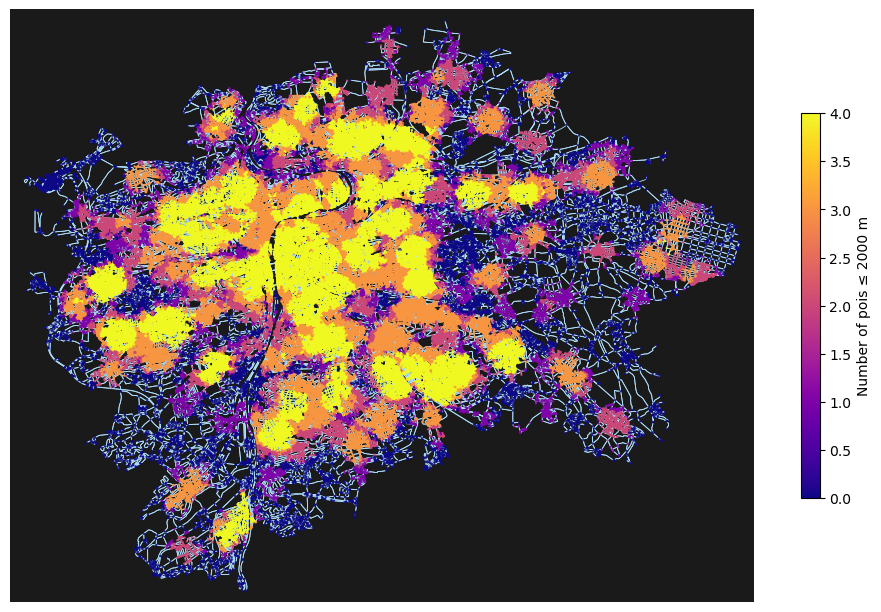

In [7]:
fig, ax = ox.plot.plot_graph(
    G,
    node_size=0,
    edge_color="#afdffe",
    edge_linewidth=0.6,
    bgcolor="#1a1a1a",
    show=False,
    close=False,
    figsize=(12,10)
)

vmin = n["pois"].min()
vmax = n["pois"].max()

n.plot(
    ax=ax,
    column="pois",
    cmap="plasma",
    markersize=0.5,
    alpha=0.8,
    legend=True,
    legend_kwds={
        "shrink": 0.5,
        "label": f"Number of pois ≤ {dist} m",
        "orientation": "vertical"
    },
    vmin=0,
    vmax=vmax
)
print(tags)
plt.show()